In [ ]:
import marimo as mo

> **Generated file.** This notebook is exported from its marimo source
> src/experiments/00_baseline/01_ukdale_baseline.py.
> Edit the source and re-export; do not edit the exported notebook by hand.

# 00 - Baseline scaffold: UK-DALE house 1

First scaffold of the baseline contract (harness, anchor, floor; statement
sections 5-7), proving the plumbing end to end on one substrate:
**UK-DALE house 1, gold layer, native cadence**. No resampled views, no
multi-house, no gates - cadence rungs get their own isolated experiment
(H03) later. Every number below is computed in this notebook; every
parameter is a provisional scaffold value, to be frozen (with
pre-registered margins) before the real baseline run.

Division of data, per the statement: submeter channels are the measured
ground truth and do the scoring; the calibration profiles are derived
from the **aggregate only**, around simulated button presses at
ground-truth onsets (the H02 calibration simulation). The quarantined
campaign in deprecated/baseline_runs/ is not reproduced here - its numbers remain
upper-bound comparison points only.

In [ ]:
# Headless rendering (export runs without a display) + notebook-local lib.
import json

import matplotlib
matplotlib.use("Agg")
import baseline_lib as bl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
# --- Parameters (frozen-lite, provisional by definition) -------------
# The full baseline run freezes this dict (plus pre-registered margins)
# before executing; nothing here is tuned against the test span.
#
# Units, used everywhere below:
#   timestamps : int64 UTC microseconds (us)
#   durations/windows : seconds, converted with _mysec = 1e6
#   power : W; energy : Wh
cfg = {
    "dataset": "ukdale",
    "house": "house_1",
    "canonicals": ["kettle", "fridge", "microwave", "washing_machine", "dishwasher"],
    "cal_frac": 0.2,  # first 20% of the span = calibration (enrollment)
    "tau_s": 12.0,  # onset-match tolerance = 2x the measured 6 s cadence
    "min_dwell_s": 30.0,  # minimum episode duration, GT and detector alike
    "merge_gap_s": 12.0,  # merge GT ON-runs separated by <= 12 s (dropped samples)
    "max_hold_s": 60.0,  # gap policy: a reading holds its value at most 60 s
    "base_win_s": 60.0,  # H02 press sim: pre-press baseline window
    "step_win_s": 30.0,  # H02 press sim: post-press step window
    "interf_win_s": 60.0,  # H02 press sim: interference look-around
    "profile_rise_frac": 0.5,  # anchor onset: forward step > 0.5 x profile dP
    "profile_fall_frac": 0.3,  # anchor offset: signal drop > 0.3 x profile dP
    "floor_rise_w": 500.0,  # floor detector: one global rise threshold (W)
    "floor_fall_frac": 0.5,  # floor offset: drop = 0.5 x rise threshold
}

In [ ]:
# presentation: parameters table
mo.md(
    "## Frozen-lite parameters\n\n"
    + bl.md_table(["parameter", "value"], [[k, v] for k, v in cfg.items()])
)

## Frozen-lite parameters

| parameter | value |
|---|---|
| dataset | ukdale |
| house | house_1 |
| canonicals | ['kettle', 'fridge', 'microwave', 'washing_machine', 'dishwasher'] |
| cal_frac | 0.2 |
| tau_s | 12.0 |
| min_dwell_s | 30.0 |
| merge_gap_s | 12.0 |
| max_hold_s | 60.0 |
| base_win_s | 60.0 |
| step_win_s | 30.0 |
| interf_win_s | 60.0 |
| profile_rise_frac | 0.5 |
| profile_fall_frac | 0.3 |
| floor_rise_w | 500.0 |
| floor_fall_frac | 0.5 |

In [ ]:
# --- Load everything once (computation) -------------------------------
# Gold layout: data/gold/<dataset>/<house>/<channel>.parquet, columns
# [ts_us (int64 us), w (float64 W)]. mains = aggregate; canonicals =
# submeter channels - the measured ground truth. They are never detector
# input: the detectors below see the aggregate only.
mains_df = bl.load_series(bl.gold_file(cfg["dataset"], cfg["house"], "mains"))
chans = {
    c: bl.load_series(bl.gold_file(cfg["dataset"], cfg["house"], c))
    for c in cfg["canonicals"]
}
# thresholds.json is quarantined (statement section 0) - adopted as-is;
# the reproducibility cell re-derives it from the channels.
with open(f"{bl.ROOT}/data/gold/thresholds.json") as fh:
    _thr_all = json.load(fh)
thr = {
    c: float(_thr_all[cfg["dataset"]][cfg["house"]][c]["thr_on_W"])
    for c in cfg["canonicals"]
}
# Hot-path arrays: timestamps (us), watts, and prefix sums of step-rule
# energy (Wh). mains_cum_wh answers "energy of [t0, t1] on mains" in
# O(log n) via window_energy_wh - used for the books and for
# per-episode attribution in the scoring cell.
mains_ts = mains_df["ts_us"].to_numpy(np.int64)
mains_w = mains_df["w"].to_numpy(float)
mains_cum_wh = bl.step_energy_cumsum_wh(mains_ts, mains_w, cfg["max_hold_s"])

In [ ]:
# --- Data health (computation: measured, not assumed) -----------------
# Per channel: row count, modal inter-sample gap (the de-facto cadence),
# and fill = rows present / rows expected at that cadence over the span.
# Fill < 100% means dropped samples, not extra data.

def _modal_dt_s(ts_us):
    """Modal positive gap in seconds, ignoring gaps >= 60 s (an outage
    is not a cadence)."""

    d = np.diff(ts_us) / 1e6
    d = d[(d > 0) & (d < 60)]
    if d.size == 0:
        return float("nan")
    vals, counts = np.unique(np.round(d, 1), return_counts=True)
    return float(vals[np.argmax(counts)])

_t0, _t1 = int(mains_ts[0]), int(mains_ts[-1])
_recs = []
for _name, _df in [("mains", mains_df)] + [(c, chans[c]) for c in sorted(chans)]:
    _ts = _df["ts_us"].to_numpy(np.int64)
    _dt = _modal_dt_s(_ts)
    # rows the channel would have if perfectly regular at its modal dt
    _fill = _ts.size / max((_ts[-1] - _ts[0]) / (_dt * 1e6), 1.0)
    _recs.append(
        {"channel": _name, "rows": int(_ts.size), "modal_dt_s": _dt, "fill": _fill}
    )
health = {"t0_us": _t0, "t1_us": _t1, "channels": _recs}

In [ ]:
# presentation: data health table + span line
_t0, _t1 = health["t0_us"], health["t1_us"]
_rows = [
    [c["channel"], f"{c['rows']:,}", f"{c['modal_dt_s']:.1f}", f"{100 * c['fill']:.0f}%"]
    for c in health["channels"]
]
mo.md(
    "## Data health (measured)\n\n"
    + bl.md_table(
        ["channel", "rows", "modal dt (s)", "modal-interval fill"], _rows
    )
    + f"\n\nSpan: {(_t1 - _t0) / 86400e6:.2f} days "
    + f"({pd.to_datetime(_t0, unit='us'):%Y-%m-%d} to {pd.to_datetime(_t1, unit='us'):%Y-%m-%d}). "
    "Fill below 100% at the modal interval = missing samples, not extra data; "
    "the gap policy (60 s hold) leaves them unintegrated. Note: the statement's "
    "dataset table calls UK-DALE mains 1 s - this house's gold mains measures at "
    "the modal interval above; worth confirming before the full run. Cadence "
    "variants are out of scope here (H03 runs that experiment)."
)

## Data health (measured)

| channel | rows | modal dt (s) | modal-interval fill |
|---|---|---|---|
| mains | 21,837,636 | 6.0 | 93% |
| dishwasher | 19,819,392 | 6.0 | 85% |
| fridge | 19,381,298 | 6.0 | 84% |
| kettle | 18,881,051 | 6.0 | 81% |
| microwave | 19,406,625 | 6.0 | 85% |
| washing_machine | 19,555,935 | 6.0 | 83% |

Span: 1628.79 days (2012-11-09 to 2017-04-26). Fill below 100% at the modal interval = missing samples, not extra data; the gap policy (60 s hold) leaves them unintegrated. Note: the statement's dataset table calls UK-DALE mains 1 s - this house's gold mains measures at the modal interval above; worth confirming before the full run. Cadence variants are out of scope here (H03 runs that experiment).

In [ ]:
# --- ON-threshold reproducibility check (computation) ------------------
# The channels are measured ground truth; the ON threshold is NOT a
# measurement - it is a labeling convention that converts a power trace
# into episode labels. It was derived once in the gold build
# (src/pipelines/03_gold_nilm/_common.py, THRESH_METHOD):
#   thr_on_W = max(5 W, 0.5 x p50 of samples above the 5 W noise floor)
#   ON := w > thr_on_W
# thresholds.json is quarantined (statement section 0). This cell
# re-derives every stored value from the channels themselves, so the
# notebook proves reproducibility instead of asserting it
# (src/pipelines/03_gold_nilm/qa_gold.py checks the same thing at gold-build time).
_recs = []
for _c, _stored in thr.items():
    _w = chans[_c]["w"].to_numpy(float)
    _nz = _w[np.isfinite(_w)]
    _nz = _nz[_nz > 5.0]
    _p50 = float(np.median(_nz))
    _mine = round(max(5.0, 0.5 * _p50), 1)
    _recs.append(
        {
            "canonical": _c,
            "stored_thr_W": _stored,
            "recomputed_thr_W": _mine,
            "p50_on_W": _p50,
            "match": bool(abs(_mine - _stored) < 0.051),
        }
    )
thr_check = pd.DataFrame(_recs)

In [ ]:
# presentation: threshold provenance + reproducibility table
_rows = [
    [
        r["canonical"],
        f"{r['stored_thr_W']:.1f}",
        f"{r['recomputed_thr_W']:.1f}",
        "yes" if r["match"] else "NO",
    ]
    for _, r in thr_check.iterrows()
]
mo.md(
    "## ON thresholds (labeling convention, not measured truth)\n\n"
    "The submeter channels are measured ground truth; the ON/OFF split is "
    "defined by a documented rule baked into the gold build "
    "(src/pipelines/03_gold_nilm/_common.py): thr = max(5 W, 0.5 x p50 of "
    "above-floor samples), ON := w > thr. thresholds.json is quarantined "
    "per statement section 0; the check column re-derives each value from "
    "the channels in this notebook (qa_gold.py verifies the same at "
    "gold-build time). A different rule relabels episodes - this is a "
    "baseline parameter to freeze, not a measurement:\n\n"
    + bl.md_table(
        ["canonical", "stored thr (W)", "recomputed (W)", "match"], _rows
    )
)

## ON thresholds (labeling convention, not measured truth)

The submeter channels are measured ground truth; the ON/OFF split is defined by a documented rule baked into the gold build (src/pipelines/03_gold_nilm/_common.py): thr = max(5 W, 0.5 x p50 of above-floor samples), ON := w > thr. thresholds.json is quarantined per statement section 0; the check column re-derives each value from the channels in this notebook (qa_gold.py verifies the same at gold-build time). A different rule relabels episodes - this is a baseline parameter to freeze, not a measurement:

| canonical | stored thr (W) | recomputed (W) | match |
|---|---|---|---|
| kettle | 1173.0 | 1173.0 | yes |
| fridge | 44.5 | 44.5 | yes |
| microwave | 762.0 | 762.0 | yes |
| washing_machine | 90.0 | 90.0 | yes |
| dishwasher | 60.5 | 60.5 | yes |

In [ ]:
# --- Ground-truth episodes (computation) -------------------------------
# Per canonical: ON := w > thr (rule above); contiguous ON runs are
# merged across gaps <= merge_gap_s (single dropped samples); runs
# shorter than min_dwell_s are dropped. Channel energy uses the same
# step rule as mains (60 s hold), so "share of mains" is like-for-like.
gt = {
    c: bl.build_episodes(
        chans[c], thr[c], cfg["min_dwell_s"], cfg["merge_gap_s"], cfg["max_hold_s"]
    )
    for c in cfg["canonicals"]
}
mains_wh_total = float(mains_cum_wh[-1])
_recs = []
for _c in cfg["canonicals"]:
    _e = gt[_c]
    _ch_ts = chans[_c]["ts_us"].to_numpy(np.int64)
    _ch_w = chans[_c]["w"].to_numpy(float)
    _ch_wh = float(bl.step_energy_cumsum_wh(_ch_ts, _ch_w, cfg["max_hold_s"])[-1])
    _recs.append(
        {
            "canonical": _c,
            "episodes": int(len(_e)),
            "median_dur_s": float(_e.dur_s.median()) if len(_e) else float("nan"),
            "channel_wh": _ch_wh,
            "share": _ch_wh / mains_wh_total,
        }
    )
gt_stats = pd.DataFrame(_recs)

In [ ]:
# presentation: GT episode table
_rows = [
    [
        r["canonical"],
        f"{int(r['episodes']):,}",
        f"{r['median_dur_s']:.0f}" if np.isfinite(r["median_dur_s"]) else "-",
        f"{r['channel_wh'] / 1000:.0f}",
        f"{100 * r['share']:.1f}%",
    ]
    for _, r in gt_stats.iterrows()
]
mo.md(
    "## Ground-truth episodes\n\n"
    "Episodes derive from the measured channels via the ON rule above; "
    "runs merged at 12 s; min dwell 30 s; energy = step rule with a 60 s "
    "hold cap (same rule as mains, so shares are like-for-like):\n\n"
    + bl.md_table(
        ["canonical", "episodes", "median dur (s)", "channel kWh", "share of mains"],
        _rows,
    )
    + f"\n\nMains total over the span: {mains_wh_total / 1000:,.0f} kWh."
    + "\n\nNote: an episode is any period above the ON rule, not a full "
    "appliance cycle. The washing_machine median (59 s) is dominated by "
    "short activations (drum/pump/valve starts): most labeled episodes "
    "last under 2 min and carry a few Wh, while the real cycles are the "
    "tail - a few thousand long episodes carry most of the class energy. "
    "Per-class labeling (min dwell / cycle grouping) is an open item for "
    "the full run's freeze; until then WM detection scores inherit these "
    "spike-dominated labels."
)

## Ground-truth episodes

Episodes derive from the measured channels via the ON rule above; runs merged at 12 s; min dwell 30 s; energy = step rule with a 60 s hold cap (same rule as mains, so shares are like-for-like):

| canonical | episodes | median dur (s) | channel kWh | share of mains |
|---|---|---|---|---|
| kettle | 6,969 | 105 | 598 | 4.1% |
| fridge | 39,666 | 1473 | 1503 | 10.2% |
| microwave | 4,155 | 47 | 304 | 2.1% |
| washing_machine | 25,883 | 59 | 1020 | 6.9% |
| dishwasher | 2,770 | 920 | 1009 | 6.9% |

Mains total over the span: 14,710 kWh.

Note: an episode is any period above the ON rule, not a full appliance cycle. The washing_machine median (59 s) is dominated by short activations (drum/pump/valve starts): most labeled episodes last under 2 min and carry a few Wh, while the real cycles are the tail - a few thousand long episodes carry most of the class energy. Per-class labeling (min dwell / cycle grouping) is an open item for the full run's freeze; until then WM detection scores inherit these spike-dominated labels.

In [ ]:
# --- Calibration / test split (computation) ----------------------------
# Time-ordered, no shuffling: the first cal_frac of the span is the
# enrollment span (profiles derive there), the rest is test. Episode
# counts per side are the starvation check - a class with zero
# calibration episodes cannot build a profile at all.
_t0, _t1 = int(mains_ts[0]), int(mains_ts[-1])
split_us = _t0 + int((_t1 - _t0) * cfg["cal_frac"])
split_counts = pd.DataFrame(
    [
        {
            "canonical": _c,
            "n_cal": int((gt[_c]["t_on_us"] < split_us).sum()),
            "n_test": int((gt[_c]["t_on_us"] >= split_us).sum()),
        }
        for _c in cfg["canonicals"]
    ]
)

In [ ]:
# presentation: split table
_rows = [
    [r["canonical"], f"{int(r['n_cal']):,}", f"{int(r['n_test']):,}"]
    for _, r in split_counts.iterrows()
]
mo.md(
    "## Calibration / test split\n\n"
    f"First {cfg['cal_frac']:.0%} of the span is calibration "
    f"(split at {pd.to_datetime(split_us, unit='us'):%Y-%m-%d}); the rest is "
    "test. Episode counts per side (starvation check - a class with no "
    "calibration episodes cannot build a profile):\n\n"
    + bl.md_table(["canonical", "calibration episodes", "test episodes"], _rows)
)

## Calibration / test split

First 20% of the span is calibration (split at 2013-10-01); the rest is test. Episode counts per side (starvation check - a class with no calibration episodes cannot build a profile):

| canonical | calibration episodes | test episodes |
|---|---|---|
| kettle | 1,152 | 5,817 |
| fridge | 7,112 | 32,554 |
| microwave | 617 | 3,538 |
| washing_machine | 5,499 | 20,384 |
| dishwasher | 388 | 2,382 |

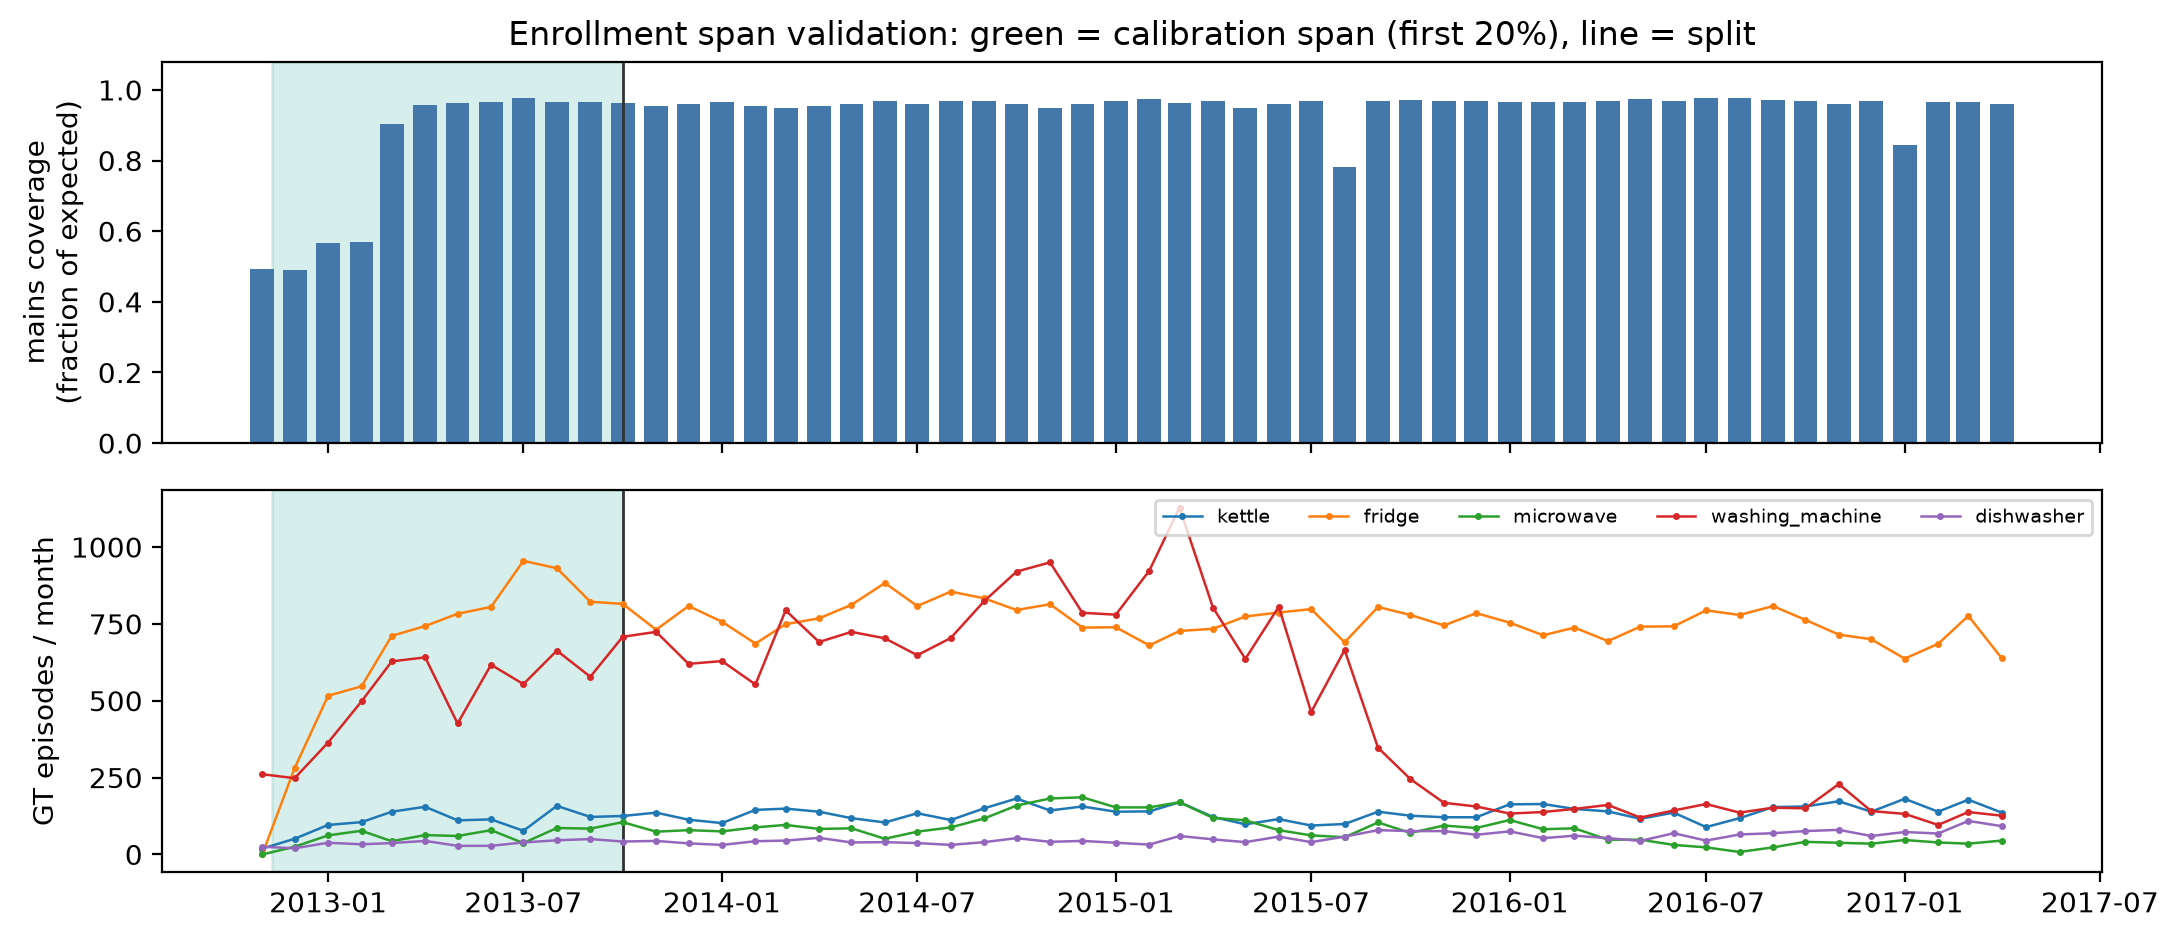

In [ ]:
# --- Visual validation of the enrollment span (figure) -----------------
# Top: monthly mains coverage = rows present / slots expected at the
#   modal cadence (6 s, measured in the health cell; 6e6 us hardcoded
#   here - cadence variants are H03's business, not this scaffold's).
# Bottom: GT episodes per month, one line per canonical.
# Green band = calibration (enrollment) span; vertical line = split.
_t0, _t1 = int(mains_ts[0]), int(mains_ts[-1])
_months = pd.period_range(
    pd.to_datetime(_t0, unit="us"), pd.to_datetime(_t1, unit="us"), freq="M"
)
_x = _months.to_timestamp()
# month boundaries in us, for searchsorted bin counting
_ms = np.array([int(m.start_time.value // 1000) for m in _months])
_me = np.array([int(m.end_time.value // 1000) + 1 for m in _months])
# rows of mains falling in each month bin
_counts = np.searchsorted(mains_ts, _me) - np.searchsorted(mains_ts, _ms)
# slots the month would hold at 6 s if perfectly regular (clamped at
# the series end so the last, partial month is not under-counted)
_exp = (np.minimum(_me, _t1) - _ms) / 6e6
_cover = np.minimum(_counts / np.maximum(_exp, 1.0), 1.0)
_fig, _axes = plt.subplots(2, 1, figsize=(11, 4.8), sharex=True)
_axes[0].bar(_x, _cover, width=22, color="#4477aa")
_axes[0].set_ylim(0, 1.08)
_axes[0].set_ylabel("mains coverage\n(fraction of expected)")
for _a in _axes:
    _a.axvspan(
        pd.to_datetime(_t0, unit="us"),
        pd.to_datetime(split_us, unit="us"),
        color="#22aa99",
        alpha=0.18,
        zorder=0,
    )
    _a.axvline(pd.to_datetime(split_us, unit="us"), color="#333333", lw=1)
for _c in ["kettle", "fridge", "microwave", "washing_machine", "dishwasher"]:
    _on = gt[_c]["t_on_us"].to_numpy(np.int64)
    # episodes of this class falling in each month bin
    _mc = np.searchsorted(_on, _me) - np.searchsorted(_on, _ms)
    _axes[1].plot(_x, _mc, marker=".", ms=3, lw=0.9, label=_c)
_axes[1].set_ylabel("GT episodes / month")
_axes[1].legend(ncol=5, fontsize=7, loc="upper right")
_axes[0].set_title(
    "Enrollment span validation: green = calibration span (first 20%), line = split"
)
_fig.tight_layout()
_fig  # noqa: B018  # render figure as cell output

**Reading the figure.** Both spans hold episodes for every canonical (no starvation), and no month is dead. Two caveats the split choice inherits: the first ~3 enrollment months have partial mains coverage (0.5-0.95) and thinner episode density (device/occupancy ramp-up), so calibration profiles lean on the stable part of the span; and washing_machine density drops sharply after mid-2015 inside the test span - a regime shift the full run's margins will have to absorb.

In [ ]:
# --- H02: button-press calibration simulation (computation) ------------
# For every ground-truth episode in the calibration span, pretend the
# occupant pressed the button at its onset, and read the profile off
# the AGGREGATE ONLY:
#   base = median mains over [on - base_win, on)   (pre-press level)
#   step = median mains over [on, on + step_win)   (post-press level)
#   dP   = step - base                             (the profile delta)
# A session is interference-flagged (and excluded) when another
# canonical's episode overlaps [on - interf_win, on + interf_win]
# (H06-lite). The class profile is the median dP over clean sessions.
# No press-time error yet - the press is exactly at the onset; H10
# sweeps on + epsilon later.
_mysec = 1_000_000  # us per second
profiles = {}
for _c in cfg["canonicals"]:
    _cal = gt[_c][gt[_c]["t_on_us"] < split_us]
    _on = _cal["t_on_us"].to_numpy(np.int64)
    # index windows into the mains arrays around each press
    _i_b0 = np.searchsorted(mains_ts, _on - cfg["base_win_s"] * _mysec)
    _i_b1 = np.searchsorted(mains_ts, _on)
    _i_s1 = np.searchsorted(mains_ts, _on + cfg["step_win_s"] * _mysec)
    _base = np.array(
        [
            np.median(mains_w[a:b]) if b > a else np.nan
            for a, b in zip(_i_b0, _i_b1)
        ]
    )
    _post = np.array(
        [
            np.median(mains_w[a:b]) if b > a else np.nan
            for a, b in zip(_i_b1, _i_s1)
        ]
    )
    _dP = _post - _base
    # interference flag, per session: some OTHER canonical has an episode
    # overlapping the look-around window. _started = #other onsets in
    # (-inf, on + interf_win]; _ended = #other offsets in
    # (-inf, on - interf_win). _started - _ended > 0 <=> at least one
    # other episode is open inside the window.
    _flagged = np.zeros(len(_cal), dtype=bool)
    for _o in cfg["canonicals"]:
        if _o == _c:
            continue
        _oe = gt[_o]
        _started = np.searchsorted(
            _oe["t_on_us"].to_numpy(np.int64),
            _on + cfg["interf_win_s"] * _mysec,
            side="right",
        )
        _ended = np.searchsorted(
            _oe["t_off_us"].to_numpy(np.int64),
            _on - cfg["interf_win_s"] * _mysec,
            side="left",
        )
        _flagged |= (_started - _ended) > 0
    _ok = ~_flagged & np.isfinite(_dP)
    profiles[_c] = {
        "sessions": int(len(_cal)),
        "flagged": int(_flagged.sum()),
        "dP_w": float(np.median(_dP[_ok])) if _ok.any() else float("nan"),
        "dwell_s": float(np.median(_cal["dur_s"].to_numpy(float)[_ok]))
        if _ok.any()
        else float("nan"),
    }

In [ ]:
# presentation: H02 profile table
mo.md(
    "## Button-press calibration simulation (H02)\n\n"
    "For each calibration episode a press is simulated at its onset; the "
    "profile comes from the aggregate only: local baseline (median mains "
    "over the 60 s before the press) and step (median mains over the 30 s "
    "after, minus that baseline). Sessions with another canonical episode "
    "inside the plus/minus 60 s look-around are interference-flagged and "
    "excluded (H06-lite). No press-time error yet - H10 sweeps that:\n\n"
    + bl.md_table(
        ["canonical", "sessions", "flagged", "profile dP (W)", "median dwell (s)"],
        [
            [
                c,
                f"{profiles[c]['sessions']:,}",
                f"{profiles[c]['flagged']:,}",
                f"{profiles[c]['dP_w']:.0f}",
                f"{profiles[c]['dwell_s']:.0f}",
            ]
            for c in cfg["canonicals"]
        ],
    )
)

## Button-press calibration simulation (H02)

For each calibration episode a press is simulated at its onset; the profile comes from the aggregate only: local baseline (median mains over the 60 s before the press) and step (median mains over the 30 s after, minus that baseline). Sessions with another canonical episode inside the plus/minus 60 s look-around are interference-flagged and excluded (H06-lite). No press-time error yet - H10 sweeps that:

| canonical | sessions | flagged | profile dP (W) | median dwell (s) |
|---|---|---|---|---|
| kettle | 1,152 | 630 | 2364 | 104 |
| fridge | 7,112 | 538 | 69 | 1297 |
| microwave | 617 | 369 | 1638 | 44 |
| washing_machine | 5,499 | 2,877 | 16 | 60 |
| dishwasher | 388 | 195 | 107 | 931 |

In [ ]:
# --- Detectors (computation; test span only) ---------------------------
# Shared step signal: at every sample, mean(next k samples) minus
# mean(previous k samples), k = step_win / cadence. rolling(k).mean()
# at index j covers w[j-k+1 .. j]; shift(-(k-1)) moves that value to
# index i, so _fwd[i] = mean(w[i .. i+k-1]); shift(1) yields
# _bwd[i] = mean(w[i-k .. i-1]). _step is a smoothed level change across
# the current sample - the same shape an H02 press produces.
_i0 = int(np.searchsorted(mains_ts, split_us, side="left"))
ts_t = mains_ts[_i0:]
_k = max(1, int(round(cfg["step_win_s"] / 6.0)))  # 30 s / 6 s cadence
_w_ser = pd.Series(mains_w[_i0:])
_fwd = _w_ser.rolling(_k).mean().shift(-(_k - 1)).to_numpy()
_bwd = _w_ser.rolling(_k).mean().shift(1).to_numpy()
_step = _fwd - _bwd
# Anchor: per-class thresholds from the H02 profile. Onset when the step
# rises above 0.5 x dP; offset when the signal has fallen back by
# 0.3 x dP (rising_edges(-step, ...) fires where step drops through
# -0.3 x dP). A prediction = (rise, next fall) pair; episodes shorter
# than min_dwell_s are discarded.
anchor_pred = {}
for _c in cfg["canonicals"]:
    _dP = profiles[_c]["dP_w"]
    if not np.isfinite(_dP) or _dP <= 0:
        anchor_pred[_c] = pd.DataFrame(columns=["t_on_us", "t_off_us", "dur_s"])
        continue
    _rise = bl.rising_edges(_step, cfg["profile_rise_frac"] * _dP)
    _fall_idx = bl.rising_edges(-_step, cfg["profile_fall_frac"] * _dP)
    anchor_pred[_c] = bl.episodes_from_edges(
        ts_t, _rise, ts_t[_fall_idx], cfg["min_dwell_s"]
    )
# Floor: one global threshold pair (500 W up, 250 W down), no profile,
# same episode pairing - the strawman the anchor must beat.
_rise_f = bl.rising_edges(_step, cfg["floor_rise_w"])
_fall_f = bl.rising_edges(-_step, cfg["floor_rise_w"] * cfg["floor_fall_frac"])
floor_pred = bl.episodes_from_edges(ts_t, _rise_f, ts_t[_fall_f], cfg["min_dwell_s"])

In [ ]:
# --- Scoring (computation; test span) -----------------------------------
# Books first: every Wh of test-span mains is either (a) attributed to a
# matched GT episode, (b) inside the always-on floor, or (c) residual.
#
# Detection quality: greedy one-to-one matching of predicted onsets to
# GT onsets within tau (baseline_lib.match_onsets); P/R/F1 from counts.
#
# Energy quality (anchor only): for each MATCHED GT episode, mains energy
# over [on, off), minus the always-on floor's share
# (always_on_w x duration; W x us / 1e6 = W*s, / 3600 = Wh), floored at
# zero, compared against the channel's own episode energy. Reported as
# the median relative error over matched episodes.
_tau_us = cfg["tau_s"] * 1e6
_i_test0 = int(np.searchsorted(mains_ts, split_us, side="left"))
_mains_wh_test = bl.window_energy_wh(
    mains_ts, mains_cum_wh, split_us, int(mains_ts[-1]) + 1
)
# always-on floor: 10th percentile of calibration-span mains - the load
# that is essentially always there and is never attributed to episodes
_always_on_w = float(np.percentile(mains_w[:_i_test0], 10))
_always_on_wh = _always_on_w * (ts_t[-1] - ts_t[0]) / 1e6 / 3600
_attributed = 0.0
score_rows = []  # [canonical, detector, n_gt, n_pred, prec, rec, f1, err or None]
margins = []  # [canonical, f1_anchor, f1_floor]
for _c in cfg["canonicals"]:
    _e = gt[_c]
    _gt_test = _e[_e["t_on_us"] >= split_us]
    _g_on = _gt_test["t_on_us"].to_numpy(np.int64)
    _f1s = {}
    for _name, _pred in [("anchor", anchor_pred[_c]), ("floor", floor_pred)]:
        _p_on = _pred["t_on_us"].to_numpy(np.int64)
        _gi, _pi = bl.match_onsets(_g_on, _p_on, _tau_us)
        _prec, _rec, _f1 = bl.prf(len(_gi), len(_p_on), len(_g_on))
        _f1s[_name] = _f1
        _err = None
        if _name == "anchor" and len(_gi):
            _off_m = _gt_test["t_off_us"].to_numpy(np.int64)[_gi]
            _e_main = np.array(
                [
                    max(
                        bl.window_energy_wh(mains_ts, mains_cum_wh, a, b)
                        - _always_on_w * (b - a) / 1e6 / 3600,
                        0.0,
                    )
                    for a, b in zip(_g_on[_gi], _off_m)
                ]
            )
            _e_gt = _gt_test["energy_wh"].to_numpy(float)[_gi]
            _attributed += float(_e_main.sum())
            _err = float(
                np.median(np.abs(_e_main - _e_gt) / np.maximum(_e_gt, 1.0))
            )
        score_rows.append(
            [_c, _name, int(len(_g_on)), int(len(_p_on)), _prec, _rec, _f1, _err]
        )
    margins.append([_c, _f1s["anchor"], _f1s["floor"]])
books = {
    "mains_wh_test": _mains_wh_test,
    "always_on_w": _always_on_w,
    "always_on_wh": _always_on_wh,
    "attributed_wh": _attributed,
    "residual_rate": 1 - (_attributed + _always_on_wh) / _mains_wh_test,
}

In [ ]:
# presentation: scoring tables (books line, detection, margins)
_rows = [
    [
        _c,
        _name,
        f"{_n_gt:,}",
        f"{_n_pred:,}",
        f"{_p:.2f}",
        f"{_r:.2f}",
        f"{_f1:.2f}",
        "-" if _err is None else f"{100 * _err:.0f}%",
    ]
    for _c, _name, _n_gt, _n_pred, _p, _r, _f1, _err in score_rows
]
mo.md(
    "## Scoring (test span)\n\n"
    "**Books first**: mains energy on test span "
    f"{books['mains_wh_test'] / 1000:,.0f} kWh; always-on floor "
    f"(calibration p10) {books['always_on_w']:.0f} W = "
    f"{books['always_on_wh'] / 1000:,.0f} kWh; attributed by matched "
    f"anchor episodes {books['attributed_wh'] / 1000:,.1f} kWh; "
    "**residual rate (unattributed share of mains): "
    f"{100 * books['residual_rate']:.1f}%**."
    "\n\nEpisode detection (onset matching, tau = 12 s, greedy one-to-one; "
    "median relative dE compares matched-episode mains energy against channel energy):\n\n"
    + bl.md_table(
        ["canonical", "detector", "GT episodes", "pred episodes", "P", "R", "F1", "median dE rel"],
        _rows,
    )
    + "\n\nMargins (anchor F1 minus floor F1) - the full run pre-registers "
    "margin values before executing; the scaffold only measures them:\n\n"
    + bl.md_table(
        ["canonical", "F1 anchor", "F1 floor", "margin"],
        [[m[0], f"{m[1]:.2f}", f"{m[2]:.2f}", f"{m[1] - m[2]:+.2f}"] for m in margins],
    )
    + "\n\nThe quarantined campaign (deprecated/baseline_runs/) is not reproduced here; "
    "its numbers stay comparison points only."
)

## Scoring (test span)

**Books first**: mains energy on test span 12,317 kWh; always-on floor (calibration p10) 156 W = 4,879 kWh; attributed by matched anchor episodes 1,008.4 kWh; **residual rate (unattributed share of mains): 52.2%**.

Episode detection (onset matching, tau = 12 s, greedy one-to-one; median relative dE compares matched-episode mains energy against channel energy):

| canonical | detector | GT episodes | pred episodes | P | R | F1 | median dE rel |
|---|---|---|---|---|---|---|---|
| kettle | anchor | 5,817 | 17,369 | 0.04 | 0.11 | 0.05 | 9% |
| kettle | floor | 5,817 | 22,455 | 0.00 | 0.01 | 0.00 | - |
| fridge | anchor | 32,554 | 132,729 | 0.03 | 0.14 | 0.06 | 52% |
| fridge | floor | 32,554 | 22,455 | 0.01 | 0.01 | 0.01 | - |
| microwave | anchor | 3,538 | 19,906 | 0.02 | 0.11 | 0.03 | 16% |
| microwave | floor | 3,538 | 22,455 | 0.01 | 0.06 | 0.02 | - |
| washing_machine | anchor | 20,384 | 307,609 | 0.01 | 0.18 | 0.02 | 142% |
| washing_machine | floor | 20,384 | 22,455 | 0.05 | 0.06 | 0.05 | - |
| dishwasher | anchor | 2,382 | 113,563 | 0.00 | 0.20 | 0.01 | 51% |
| dishwasher | floor | 2,382 | 22,455 | 0.02 | 0.18 | 0.03 | - |

Margins (anchor F1 minus floor F1) - the full run pre-registers margin values before executing; the scaffold only measures them:

| canonical | F1 anchor | F1 floor | margin |
|---|---|---|---|
| kettle | 0.05 | 0.00 | +0.05 |
| fridge | 0.06 | 0.01 | +0.05 |
| microwave | 0.03 | 0.02 | +0.02 |
| washing_machine | 0.02 | 0.05 | -0.03 |
| dishwasher | 0.01 | 0.03 | -0.03 |

The quarantined campaign (deprecated/baseline_runs/) is not reproduced here; its numbers stay comparison points only.

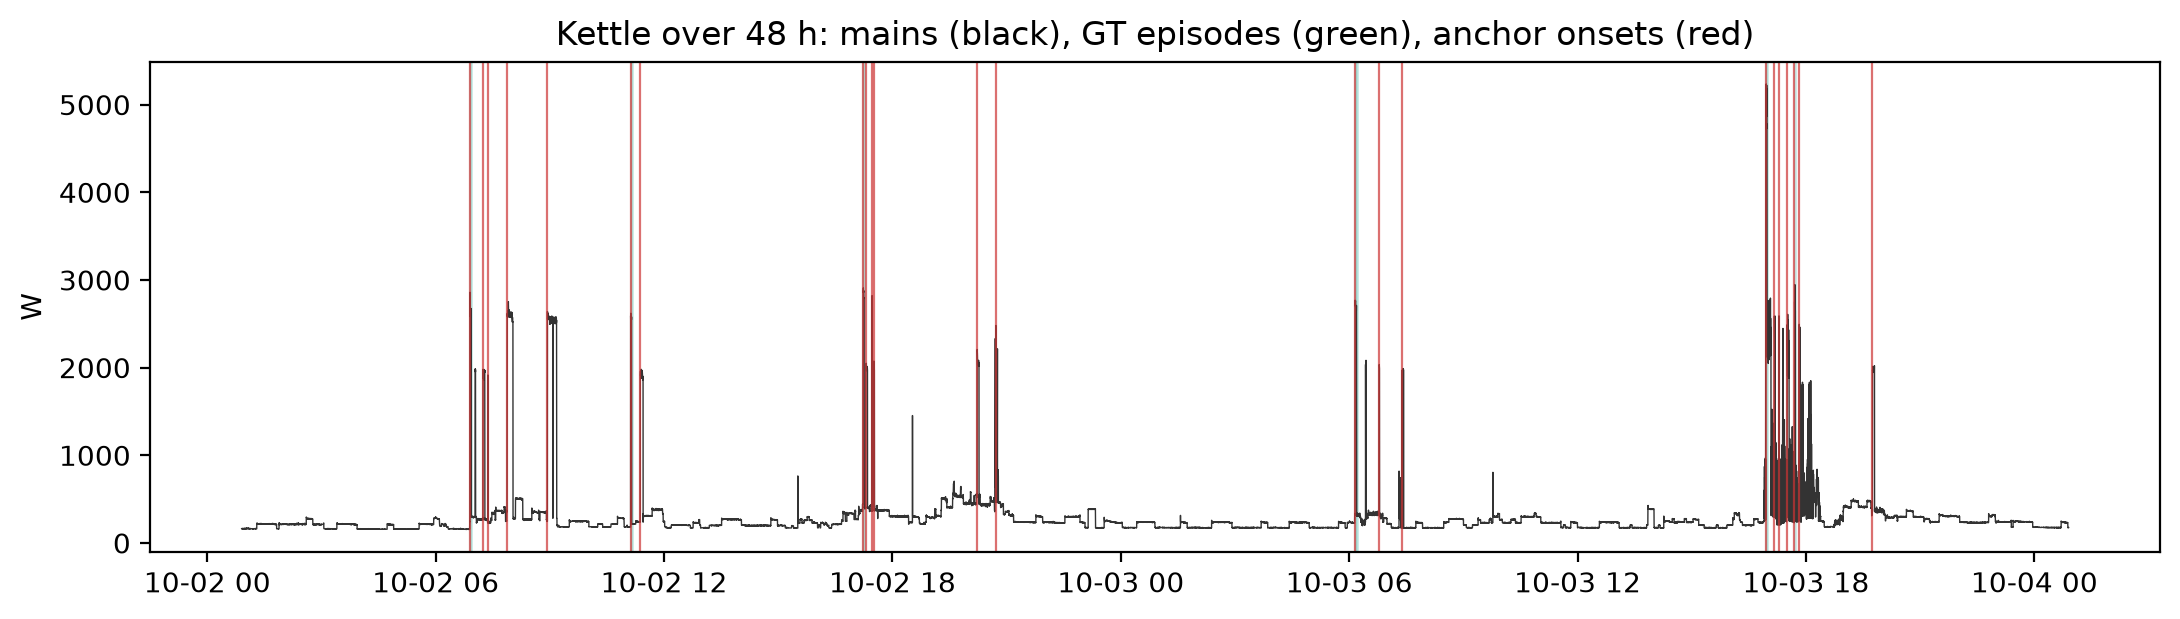

In [ ]:
# --- Spot check: kettle over the first 48 h of test (figure) -----------
# Black = mains trace. Green spans = GT episodes (from the kettle's own
# submeter). Red lines = onsets the anchor detector fired from the
# aggregate alone. Green without red = miss; red without green = false
# trigger. This is an eyeball check, not a metric.
_c = "kettle"
_e = gt[_c]
_test = _e[_e["t_on_us"] >= split_us]
# window: 6 h before the first test-span kettle episode, 48 h long
_w0 = int(_test["t_on_us"].iloc[0] - 6 * 3600e6) if len(_test) else int(mains_ts[0])
_w1 = _w0 + 48 * 3600e6
_a = int(np.searchsorted(mains_ts, _w0))
_b = int(np.searchsorted(mains_ts, _w1))
_fig, _ax = plt.subplots(figsize=(11, 3.2))
_ax.plot(
    pd.to_datetime(mains_ts[_a:_b], unit="us"), mains_w[_a:_b], lw=0.5, color="#333333"
)
for _, r in _test[(_test["t_on_us"] >= _w0) & (_test["t_on_us"] < _w1)].iterrows():
    _ax.axvspan(
        pd.to_datetime(int(r["t_on_us"]), unit="us"),
        pd.to_datetime(int(r["t_off_us"]), unit="us"),
        color="#22aa99",
        alpha=0.25,
    )
for t in anchor_pred[_c]["t_on_us"]:
    if _w0 <= t < _w1:
        _ax.axvline(pd.to_datetime(int(t), unit="us"), color="#cc3333", lw=0.8, alpha=0.7)
_ax.set_ylabel("W")
_ax.set_title("Kettle over 48 h: mains (black), GT episodes (green), anchor onsets (red)")
_fig.tight_layout()
_fig  # noqa: B018  # render figure as cell output

## Deliberately not in this scaffold

- **Cadence rungs** (60 s / 300 s views, collapse table): H03 runs that as its own isolated experiment.
- **Press-time error** (press at onset plus epsilon, sensitivity sweep): H10.
- **Full interference rule** for profile sessions: H06 (the scaffold uses the lite flag only).
- **Pre-registered margins**: frozen before the full run executes; the scaffold only measures anchor minus floor.
- **Microwave in/out of the canonical set**: statement section 10 open item; the scaffold keeps all five.
- **Per-class episode labeling**: the washing_machine labels are spike-dominated (short activations, not cycles); per-class min dwell / cycle grouping is decided at the full run's freeze, not here.
- **Multi-house separation** (statement section 7): house 1 only here.
- **pytest coverage for baseline_lib** (episode builder, matcher, step-energy rule) in tests/.